# 02 - Ablation Analysis

How much does each pipeline stage (cleaning -> smoothing -> lag features -> full
feature set) actually buy in predictive accuracy, for Dissolved Oxygen forecasting?
Uses `experiments/results/stage_metrics.json`, produced by `experiments/run_ablation.py`
across five representative models (persistence, linear regression, random forest,
XGBoost, LSTM) spanning the statistical / classical ML / deep learning families -
running the entire 20-model registry at every one of the four stages would multiply an
already expensive training bill for no extra insight into what the *preprocessing*
buys you.

In [1]:
import sys
sys.path.append('..')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RESULTS_DIR, REPORTS_DIR, PRIMARY_TARGET
from src.pipeline import build_base_artifacts, build_stage_dataframe, prepare_model_data
from src.models.registry import build_model
from src.evaluation import residuals

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

stage_metrics = pd.DataFrame(json.load(open(RESULTS_DIR / 'stage_metrics.json')))
stage_metrics.head()

I0000 00:00:1784383766.927831  165219 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784383766.928192  165219 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784383766.957645  165219 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784383767.667664  165219 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784383767.667896  165219 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


,stage,target,model,split,mae,rmse,mape,r2,n
0,cleaned,Dissolved Oxygen,persistence,train,0.069478,0.128839,1.075199,0.955714,18580
1,cleaned,Dissolved Oxygen,persistence,val,0.139713,0.218878,2.166365,0.889686,3981
2,cleaned,Dissolved Oxygen,persistence,test,0.198192,0.271910,2.854595,0.719324,3982
3,cleaned,Dissolved Oxygen,linear_regression,train,0.069778,0.123289,1.073847,0.959447,18580
4,cleaned,Dissolved Oxygen,linear_regression,val,0.133021,0.204533,2.062465,0.903672,3981


## 1. Stage-wise test MAE, per model

Only the `test` split matters for the ablation question - train/val are there
for overfitting diagnostics, not for judging preprocessing value.

In [2]:
test_only = stage_metrics[stage_metrics['split'] == 'test'].copy()
stage_order = ['cleaned', 'smoothed', 'lag_features', 'full_features']
test_only['stage'] = pd.Categorical(test_only['stage'], categories=stage_order, ordered=True)
pivot = test_only.pivot_table(index='model', columns='stage', values='mae')
pivot

stage,cleaned,smoothed,lag_features,full_features
model,,,,
linear_regression,0.183582,0.129593,0.096841,0.096577
lstm,0.208550,0.104248,0.366753,0.833442
persistence,0.198192,0.198192,0.202946,0.202946
random_forest,0.205843,0.145644,0.118699,0.119271
xgboost,0.205884,0.145348,0.116851,0.117363


## 2. Waterfall view - marginal MAE improvement per stage

For each model, how much does MAE drop moving from one stage to the next.
Negative deltas = improvement (lower MAE is better).

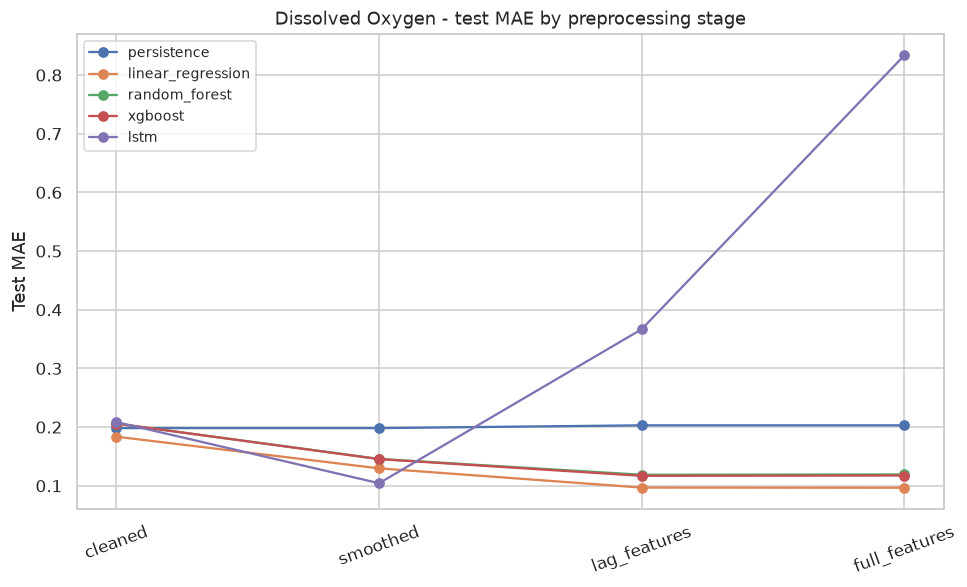

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for model in test_only['model'].unique():
    m = test_only[test_only['model'] == model].sort_values('stage')
    ax.plot(m['stage'], m['mae'], marker='o', label=model)
ax.set_title('Dissolved Oxygen - test MAE by preprocessing stage')
ax.set_ylabel('Test MAE')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../reports/ablation_stage_mae.png', bbox_inches='tight')
plt.show()

In [4]:
waterfall_rows = []
for model, row in pivot.iterrows():
    prev = None
    for stage in stage_order:
        if stage not in row or pd.isna(row[stage]):
            continue
        delta = None if prev is None else row[stage] - prev
        waterfall_rows.append({'model': model, 'stage': stage, 'mae': row[stage], 'delta_from_prev_stage': delta})
        prev = row[stage]
waterfall_df = pd.DataFrame(waterfall_rows)
waterfall_df

,model,stage,mae,delta_from_prev_stage
0,linear_regression,cleaned,0.183582,NaN
1,linear_regression,smoothed,0.129593,-0.053989
2,linear_regression,lag_features,0.096841,-0.032752
3,linear_regression,full_features,0.096577,-0.000264
4,lstm,cleaned,0.208550,NaN
5,lstm,smoothed,0.104248,-0.104302
6,lstm,lag_features,0.366753,0.262505
7,lstm,full_features,0.833442,0.466689
8,persistence,cleaned,0.198192,NaN
9,persistence,smoothed,0.198192,0.000000


## 3. Residual analysis for the best full-registry model

Loads `model_comparison.json` to find the best model, retrains it on the
full_features stage, and looks at the residual distribution - is the error
symmetric, or does the model systematically over/under-predict at the extremes?

In [5]:
comparison = pd.DataFrame(json.load(open(RESULTS_DIR / 'model_comparison.json')))
comparison_ok = comparison[comparison['status'] == 'ok'].copy()
best_row = comparison_ok.loc[comparison_ok['test_mae'].idxmin()]
best_row[['target', 'model', 'test_mae', 'test_rmse', 'test_r2']]

target        Dissolved Oxygen
model        linear_regression
test_mae              0.096577
test_rmse             0.132803
test_r2               0.931982
Name: 1, dtype: object

2026-07-18 19:39:28,419 | INFO     | src.data_loader | Loading raw CSV from /home/icarus/DO_Predictor/data/raw/brisbane_water_quality.csv


2026-07-18 19:39:28,458 | INFO     | src.data_loader | Dropped pH column(s) ['pH', 'pH [quality]'] - this system is Dissolved-Oxygen-only.


2026-07-18 19:39:28,458 | INFO     | src.data_loader | Loaded 30894 rows, 18 columns.


2026-07-18 19:39:28,470 | INFO     | src.validation | Validation done: 30894 rows, 280 dup timestamps, 7 quality cols kept, 0 dropped, modal cadence=10.0 min.


2026-07-18 19:39:28,470 | INFO     | src.validation | note: 280 duplicate Timestamp values (different Record numbers, same clock reading) - resolved in cleaning.py.


...

2026-07-18 19:39:28,542 | INFO     | src.cleaning | Flagged 435 outlier readings across all sensors (not dropped).


2026-07-18 19:39:28,543 | INFO     | src.cleaning | Cleaning pipeline complete: 47149 rows in final frame.


2026-07-18 19:39:28,566 | INFO     | src.smoothing | Added moving-average and Savitzky-Golay columns for 9 sensors.


2026-07-18 19:39:28,691 | INFO     | src.pipeline | Cached processed dataset to /home/icarus/DO_Predictor/data/processed/brisbane_water_quality_clean.parquet


2026-07-18 19:39:29,011 | INFO     | src.feature_engineering | Built feature matrix: 165 columns for target 'Dissolved Oxygen'.


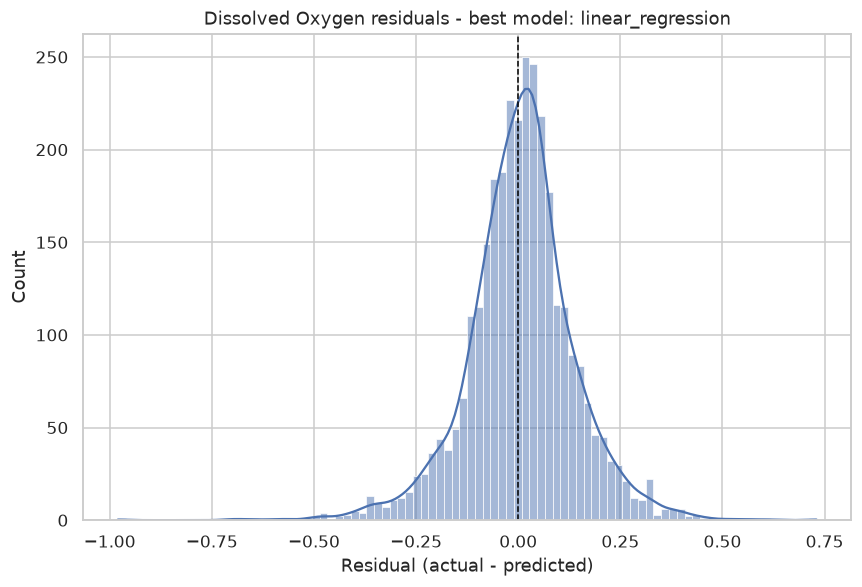

In [6]:
base = build_base_artifacts()

model_name = best_row['model']
stage_df = build_stage_dataframe(base, PRIMARY_TARGET, 'full_features')
splits = prepare_model_data(stage_df, PRIMARY_TARGET, model_name)
X_train, y_train = splits['train']
X_val, y_val = splits['val']
X_test, y_test = splits['test']

model = build_model(model_name, PRIMARY_TARGET)
model.fit(X_train, y_train, X_val, y_val)
preds = model.predict(X_test)
y_true = y_test.iloc[-len(preds):]
resid = residuals(y_true.to_numpy(), preds)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.histplot(resid, kde=True, ax=ax, color='#4C72B0')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title(f'Dissolved Oxygen residuals - best model: {model_name}')
ax.set_xlabel('Residual (actual - predicted)')
plt.tight_layout()
plt.savefig('../reports/ablation_residuals.png', bbox_inches='tight')
plt.show()

## 4. Error distribution across model families

Boxplot of test MAE by model category (statistical / classical ML / deep
learning), from the full model comparison at the final feature stage.

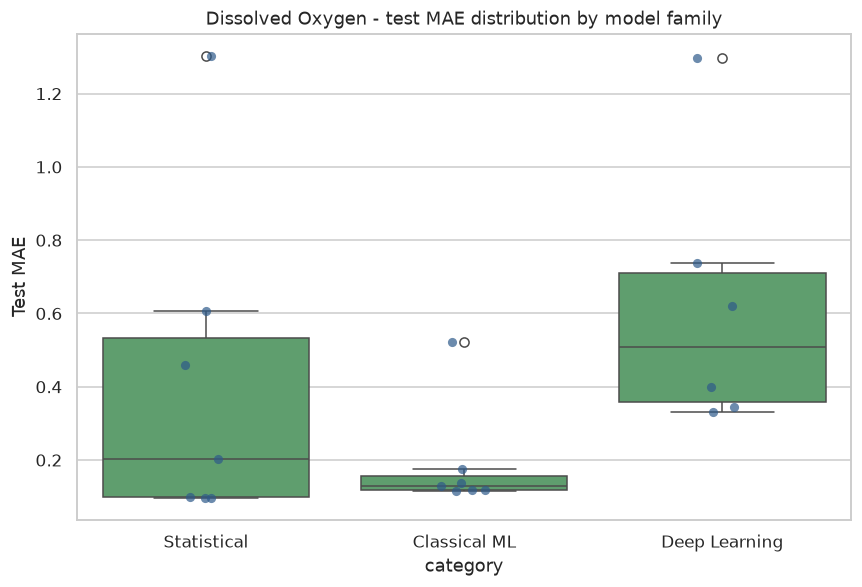

In [7]:
from src.models.registry import STATISTICAL_MODELS, CLASSICAL_ML_MODELS, DEEP_LEARNING_MODELS

def category_of(name):
    if name in STATISTICAL_MODELS:
        return 'Statistical'
    if name in CLASSICAL_ML_MODELS:
        return 'Classical ML'
    if name in DEEP_LEARNING_MODELS:
        return 'Deep Learning'
    return 'Other'

comparison_ok['category'] = comparison_ok['model'].apply(category_of)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=comparison_ok, x='category', y='test_mae', ax=ax, color='#55A868')
sns.stripplot(data=comparison_ok, x='category', y='test_mae', ax=ax, color='#2E5A8A', alpha=0.7, size=6)
ax.set_ylabel('Test MAE')
ax.set_title('Dissolved Oxygen - test MAE distribution by model family')
plt.tight_layout()
plt.savefig('../reports/ablation_error_by_family.png', bbox_inches='tight')
plt.show()

## Summary

The stage sweep isolates what cleaning, smoothing, and feature engineering each
contribute independently of model choice - see the waterfall table in section 2
for exact numbers. The residual plot in section 3 checks whether the best model
is unbiased (residuals centered near zero) rather than just low-MAE-on-average,
and section 4 compares error spread across model families rather than single
point estimates.